<a href="https://colab.research.google.com/github/mndungu-robert/Data_Wrangling/blob/main/Airplanes_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

Determine the number of rows and columns in the dataset


In [4]:
rows, columns = df.shape
print(f"Rows: {rows} columns: {columns}")


Rows: 5268 columns: 13


Display the last 75 rows in the dataset

In [6]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


Each column except the first one has some missing data. For each column, name
the most appropriate method for treating the missing data. Justify your choices.


In [23]:
missing_values = df.isnull().sum()

print(missing_values)
#df.info()

missing_treatment = {
    "Time": "Keep missing values or replace with 'Unknown' because the exact time may not be available.",
    "Location": "Investigate missing values and use 'Unknown' if the location cannot be recovered.",
    "Operator": "Use 'Unknown' if the operator is not recorded.",
    "Flight number": "Use 'Unknown' because flight numbers are categorical and cannot be reliably inferred.",
    "Route": "Use 'Unknown' if the route is unavailable.",
    "Type": "Use 'Unknown' if the aircraft type is not recorded.",
    "Registration": "Use 'Unknown' if the registration is missing.",
    "cn/In": "Use 'Unknown' if the aircraft construction number is missing.",
    "Aboard": "Investigate the missing values; use a suitable imputation method only if justified.",
    "Fatalities": "Investigate the missing values; do not automatically replace with zero.",
    "Ground": "Use a justified numerical imputation method or investigate the original record.",
    "Summary": "Use 'No summary available' if the description is missing."
}

for column, method in missing_treatment.items():
    print(f"{column}: {method}")

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64
Time: Keep missing values or replace with 'Unknown' because the exact time may not be available.
Location: Investigate missing values and use 'Unknown' if the location cannot be recovered.
Operator: Use 'Unknown' if the operator is not recorded.
Flight #: Use 'Unknown' because flight numbers are categorical and cannot be reliably inferred.
Route: Use 'Unknown' if the route is unavailable.
Type: Use 'Unknown' if the aircraft type is not recorded.
Registration: Use 'Unknown' if the registration is missing.
cn/In: Use 'Unknown' if the aircraft construction number is missing.
Aboard: Investigate the missing values; use a suitable imputation method only if justified.
Fatalities: Investigate the missing values;

Create a new dataframe from the raw/uncleaned data called
‘fatality_locations’ with the following columns: ‘Date’,
‘Location’, ‘Aboard’, ‘Fatalities’.


In [7]:
fatality_locations = df[["Date", "Location", "Aboard", "Fatalities"]].copy()

fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


Determine the date of the highest number of recorded fatalities from this new
dataframe.


In [14]:
highest_fatality_index = fatality_locations["Fatalities"].idxmax()

print("Date:", fatality_locations.loc[highest_fatality_index, "Date"])
#print("Fatalities:", fatality_locations.loc[highest_fatality_index, "Fatalities"])

Date: 03/27/1977


 Compare the number of passengers aboard to the number of fatalities per crash. Are
there any recorded crashes where there were no fatalities? If so, how many?


In [15]:
fatality_locations[["Aboard", "Fatalities"]]

no_fatalities = fatality_locations[
    fatality_locations["Fatalities"] == 0
]

print("Number of crashes with no fatalities:", len(no_fatalities))

#no_fatalities

Number of crashes with no fatalities: 58


In the ‘fatality_locations’ dataframe, the location column has data items
represented as ‘Region, U.S. State/Country’. Split this column to have two columns
of regions and states/countries.

In [17]:
split_data = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

fatality_locations['Region'] = split_data[0].str.strip()
fatality_locations['State_Country'] = split_data[1].str.strip() if 1 in split_data.columns else np.nan

fatality_locations['State_Country'] = fatality_locations['State_Country'].fillna(fatality_locations['Region'])
fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State/Country,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada,Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None,Over the North Sea
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany,Germany


Order the dataframe by the number of fatalities from highest to lowest and select the
first 100.


In [19]:
top_100_fatality_locations = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatality_locations

,Date,Location,Aboard,Fatalities,Region,State/Country,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan,Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland,110 miles West of Ireland
...,...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran,Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia,Russia


Generate a pie chart that shows the distribution of the top 25 number of fatalities
per country/U.S. State.

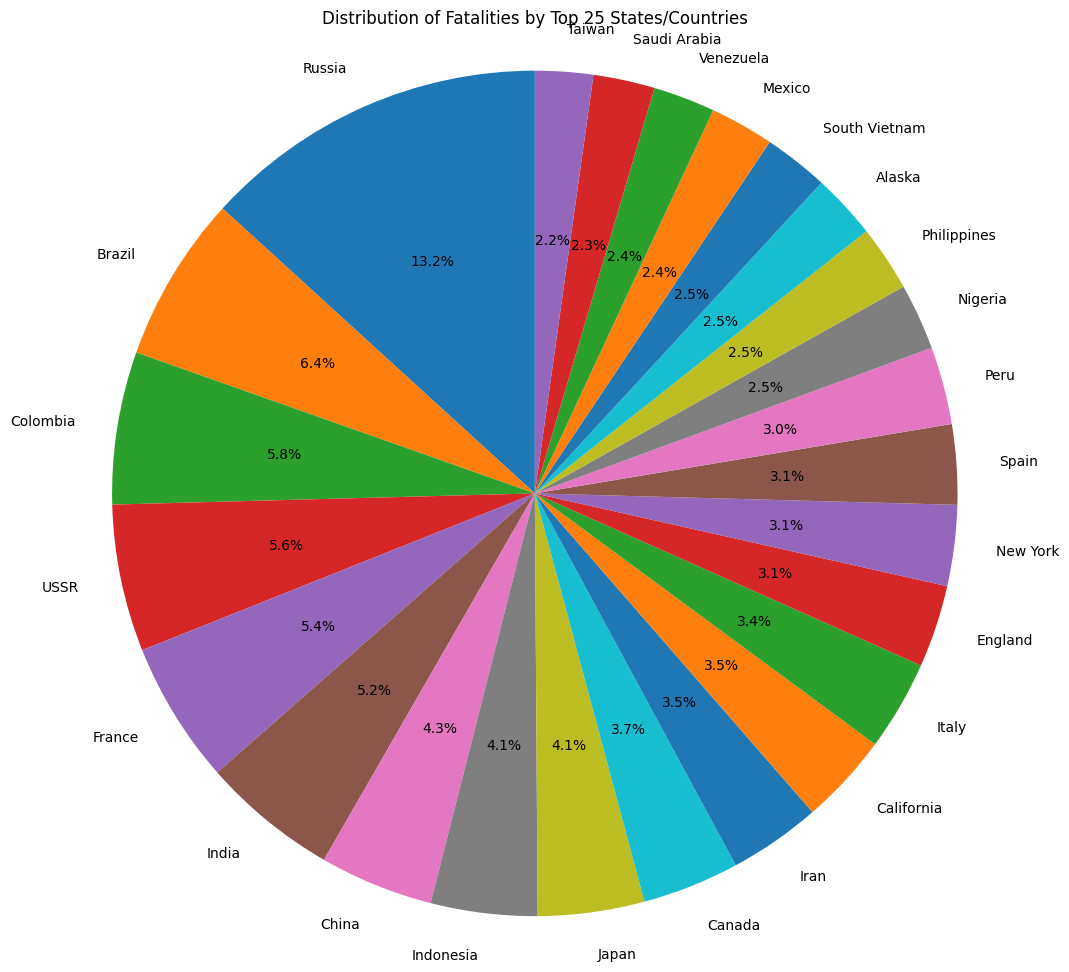

In [20]:
country_fatalities = (
    fatality_locations
    .groupby("State/Country")["Fatalities"]
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(12, 12))

plt.pie(
    country_fatalities,
    labels=country_fatalities.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Fatalities by Top 25 States/Countries")
plt.axis("equal")
plt.show()